# Making my own 6-km gridded obs - DBZ only

In [2]:
import sys
import os
#import numpy as N
import math as M
import datetime as DT 
from netCDF4 import *
import pyDart
import ens 
import glob
from optparse import OptionParser
from multiprocessing import Pool
from time import time as timer
from nc_prior_file import *
from assim_util import *
import state_vector as state
import json
import ctables
import xarray as xr


from pyDart import dxy_2_dll
import pandas as pd
import pickle
import numpy as np
import cftime

import matplotlib.pyplot as plt

import matplotlib as mpl    
plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14) 
plt.rc('axes', labelsize=14, titlesize=18) 
mpl.rcParams.update({"axes.grid" : False, "grid.color": "0.6",  'grid.linestyle':':',
                    'grid.linewidth':1, 'axes.labelweight':'bold', 'legend.framealpha':1.0})

def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()

def get_dbz(analysis_time, experiment):
    myDTstring = analysis_time.strftime('%Y,%m,%d,%H,%M,%S')
    with open(f'/work/jessica.mcdonald/CM1_LETKF_2025/{experiment}/{experiment}.exp', 'rb') as f:
        exper = json.load(f)
    files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False,);
    
    mystate = ens.read_CM1_ens(files, exper, state_vector=state.Hxf, DateTime=analysis_time)   
    ens.ens_CM1_C2A(mystate)
    ens.ens_CM1_coords(mystate)
    
    obs = ens.ens_GRID_RELECTIVITY(mystate, cref=False)
    return obs   


In [3]:
from scipy.interpolate import RegularGridInterpolator

names = ['Hxa_bar', 'Hxb_bar','azimuth', 'cov_group', 'd', 'date', 'days', 'dep', 'elevation', 
            'error_var', 'height', 'index', 'kind', 'lat', 'lon', 'next', 'number', 'platform_dir1', 'platform_dir2', 'platform_dir3',
             'platform_height', 'platform_key', 'platform_lon', 'platform_lat', 'platform_nyquist', 'platform_vert_coord','previous',
              'sdHxa','sdHxb','seconds','utime','value','vert_coord', 'x', 'x_m', 'y', 'y_m', 'z']

day_utime   = "days since 1601-01-01 00:00:00"#utime("days since 1601-01-01 00:00:00") JEDIT
sec_utime   = "seconds since 1970-01-01 00:00:00"#utime("seconds since 1970-01-01 00:00:00") JEDIT

truelat1, truelat2 = 30.0, 60.0
map_projection='lcc'

allfiles = sorted(glob.glob('/work/jessica.mcdonald/LETKF_Nature_Run/cm1out_0*'))

In [4]:
# from create_run_letkf for reference lat/lon
radar_lat =  35.23583
radar_lon = -97.46194

total_count = 0
start_time = DT.datetime(2024,5,8,20)

for i,f in enumerate(allfiles[8:21]):
    print(f)

    data_time = start_time + DT.timedelta(minutes=i*5)

    cm1 = xr.open_dataset(f, decode_timedelta=True)

    x,y = cm1.xh.values, cm1.yh.values 
    
    for lev in [1,3,5,8]:
        data = cm1.dbz[0,lev,:,:].values
        interp = RegularGridInterpolator((y,x), data)
        y6km, x6km = np.meshgrid(cm1.yh[::6], cm1.xh[::6])
        dbz = interp((y6km, x6km)).reshape(np.shape(y6km))

        #keep1 = np.where(dbz.flatten() == 0.0)[0][::3]
        # only keep every 3rd point in both x and y direction... so ~18 km spacing
        # then keep wherever dbz >0
        # keep1 = np.cumsum(np.zeros_like(dbz) + 1).astype(int).reshape(np.shape(dbz))[::3,::3].flatten()-1
        # keep2 = np.where(dbz.flatten() > 0 )[0]
        # keep = list(set(np.concat([keep1, keep2])))

        # pretend that radar is in lower left corner
        r = np.hypot(y6km, x6km)
        u_interp = RegularGridInterpolator((y,x), cm1.uinterp[0,lev,:,:].values)
        v_interp = RegularGridInterpolator((y,x), cm1.vinterp[0,lev,:,:].values)
        ui = u_interp((y6km, x6km)).reshape(np.shape(y6km))
        vi = v_interp((y6km, x6km)).reshape(np.shape(y6km))
        vr = (x6km/r)*ui + (y6km/r)*vi

        # try not to break the forward operator
        azimuths = np.rad2deg(np.arctan2((x6km.copy()-180)*1000,(y6km.copy()-180)*1000))

        # nan out vr where dbz == 0, and drop later
        vr[dbz == 0.0] = np.nan
        dbz[dbz == 0.0]= np.nan
                

        for idx, dataset in enumerate([vr, dbz]):## do not change order!

            temp = pd.DataFrame(columns=names)

            N_obs = len(x6km.flatten())
            temp['x']         = x6km.flatten()*1000
            temp['y']         = y6km.flatten()*1000
            temp['z']         = [lev*1000]*N_obs
            temp['value']     = dataset.flatten()
            temp['kind']      = [11 + idx]*N_obs # kinda scary way to control kind value. this will be 11 for vr and 12 for dbz
            temp['error_var'] = [4]*N_obs
            temp['date']      = [data_time]*N_obs
            temp['days']      = int(cftime.date2num(data_time,day_utime))*N_obs
            temp['seconds']   = [data_time.hour*3600 + data_time.minute*60]*N_obs
            temp['utime']     = [cftime.date2num(data_time,sec_utime)]*N_obs

            temp['elevation'] = 0 # just set this to zero for now
            temp['azimuth']   = azimuths.flatten()

            ### now drop a bunch every other clear air ob
            #temp = temp.iloc[keep]
            
            # drop all nans
            temp = temp[np.isnan(temp.value)==False]
    
            if total_count ==0:
                subdata = temp.copy()
            else:
                subdata = pd.concat([subdata, temp], ignore_index=True)
            total_count+=1
    cm1.close()
    
subdata['x'] = subdata['x']   - 180000 ## these are the "xoffset" listed in create_run_letkf
subdata['y'] = subdata['y']   - 180000     
ob_lats, ob_lons = dxy_2_dll(subdata['x'], subdata['y'], radar_lat, radar_lon)
subdata['lat'] = ob_lats
subdata['lon'] = ob_lons
subdata['height'] = subdata['z']

### now, drop nan Vr
#subdata = subdata[np.isnan(subdata.value)==False]

#subdata.to_csv('Obs/8may24_cm1_dbzonly.csv', index=None)
subdata.to_csv('Obs/8may24_cm1_obs.csv', index=None)

print(len(subdata)/13)

/work/jessica.mcdonald/LETKF_Nature_Run/cm1out_000009.nc
/work/jessica.mcdonald/LETKF_Nature_Run/cm1out_000010.nc
/work/jessica.mcdonald/LETKF_Nature_Run/cm1out_000011.nc
/work/jessica.mcdonald/LETKF_Nature_Run/cm1out_000012.nc
/work/jessica.mcdonald/LETKF_Nature_Run/cm1out_000013.nc
/work/jessica.mcdonald/LETKF_Nature_Run/cm1out_000014.nc
/work/jessica.mcdonald/LETKF_Nature_Run/cm1out_000015.nc
/work/jessica.mcdonald/LETKF_Nature_Run/cm1out_000016.nc
/work/jessica.mcdonald/LETKF_Nature_Run/cm1out_000017.nc
/work/jessica.mcdonald/LETKF_Nature_Run/cm1out_000018.nc
/work/jessica.mcdonald/LETKF_Nature_Run/cm1out_000019.nc
/work/jessica.mcdonald/LETKF_Nature_Run/cm1out_000020.nc
/work/jessica.mcdonald/LETKF_Nature_Run/cm1out_000021.nc
511.0769230769231


In [201]:
subdata[subdata.utime == subdata.utime.values[0]]

,Hxa_bar,Hxb_bar,azimuth,cov_group,d,date,days,dep,elevation,error_var,...,sdHxb,seconds,utime,value,vert_coord,x,x_m,y,y_m,z
337,NaN,NaN,-141.398956,NaN,NaN,2024-05-08 20:00:00,633344000,NaN,0,4,...,NaN,72000,1715198400,4.967744,NaN,-47500.00000,NaN,-59499.992188,NaN,1000
339,NaN,NaN,-138.399704,NaN,NaN,2024-05-08 20:00:00,633344000,NaN,0,4,...,NaN,72000,1715198400,4.523743,NaN,-47500.00000,NaN,-53499.992188,NaN,1000
354,NaN,NaN,-147.642151,NaN,NaN,2024-05-08 20:00:00,633344000,NaN,0,4,...,NaN,72000,1715198400,8.332845,NaN,-41500.00000,NaN,-65499.992188,NaN,1000
355,NaN,NaN,-145.105026,NaN,NaN,2024-05-08 20:00:00,633344000,NaN,0,4,...,NaN,72000,1715198400,3.229383,NaN,-41500.00000,NaN,-59499.992188,NaN,1000
356,NaN,NaN,-142.199234,NaN,NaN,2024-05-08 20:00:00,633344000,NaN,0,4,...,NaN,72000,1715198400,5.366087,NaN,-41500.00000,NaN,-53499.992188,NaN,1000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4135,NaN,NaN,57.491474,NaN,NaN,2024-05-08 20:00:00,633344000,NaN,0,4,...,NaN,72000,1715198400,0.000000,NaN,198500.03125,NaN,126500.000000,NaN,8000
4136,NaN,NaN,53.946892,NaN,NaN,2024-05-08 20:00:00,633344000,NaN,0,4,...,NaN,72000,1715198400,0.000000,NaN,198500.03125,NaN,144500.031250,NaN,8000
4137,NaN,NaN,50.694878,NaN,NaN,2024-05-08 20:00:00,633344000,NaN,0,4,...,NaN,72000,1715198400,0.000000,NaN,198500.03125,NaN,162500.031250,NaN,8000
4138,NaN,NaN,47.719128,NaN,NaN,2024-05-08 20:00:00,633344000,NaN,0,4,...,NaN,72000,1715198400,0.000000,NaN,198500.03125,NaN,180500.031250,NaN,8000


In [194]:
idx, Hxf, kind, lat, lon, height, elev, azimuth = ens.calcHx(state, 
                                                               subdata['kind'].values, 
                                                               subdata['lat'].values,                                         
                                                               subdata['lon'].values,
                                                               subdata['height'].values,
                                                               subdata['elevation'].values,
                                                               subdata['azimuth'].values)

AttributeError: module 'state_vector' has no attribute 'ne'

In [182]:
analysis_time = DT.datetime(2024, 5, 8, 20, 30)

In [180]:
dbz = get_dbz(analysis_time, 'DBZ_only')

xh, yh = np.meshgrid(np.arange(.5, 378.5+4, 3),np.arange(.5, 378.5+4, 3))
zh = [0.025,0.082,0.154,0.239,0.339,0.454,0.582,0.725,0.882,1.054,1.239,1.439,1.654,1.882,2.125,2.382,2.654,\
    2.939,3.239,3.554,3.882,4.225,4.582,4.954,5.339,5.739,6.154,6.582,7.025,7.482,7.954,8.439,8.939,9.454,9.982,\
    10.525,11.082,11.654,12.239,12.839,13.454,14.082,14.725,15.382,16.054,16.739,17.439,18.154,18.882,19.625]


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:30:00

 ==> FindRestartFile:  Found time 4500 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/DBZ_only/member001/cm1rst_000015.nc

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 20:30:00 


 Wallclock time for serial read netCDF ensemble files: 1.368  sec

 Wallclock time to convert from C to A grid: 0.313  sec

 Wallclock time to read arrays from netCDF ensemble files: 1.786  sec

 Wallclock time to convert from C to A grid: 0.314  sec

 Wallclock time to create coordinates: 0.0  sec
 FORTRAN OBS_2_GRID3D:  dims           128         128          51        2162
 FORTRAN OBS_2_GRID3D:  dx, hscale   3000.00000       4000.00000    
 FORTRAN OBS_2_GRID3D:  dy, hscale   3000.00000       4000.00000    
 FORTRAN OBS_2_GRID3D:  vscale     2000.00000    
 FORTRAN OBS_2_GRID3D:    obs    0.00000000       44.5815811    
 FORTRAN OBS_2_GRID3D:  x-obs   -184932.531       200830.4

In [191]:
times = np.unique(subdata.utime)
time_idx = 5
kind = 12
height = 1000

temp = subdata[(subdata.kind==kind)&(subdata.height==1000)&(pd.to_datetime(subdata.date) == analysis_time)]

In [189]:
np.any(pd.to_datetime(subdata.date) == analysis_time)

np.True_

TypeError: scatter() missing 2 required positional arguments: 'x' and 'y'

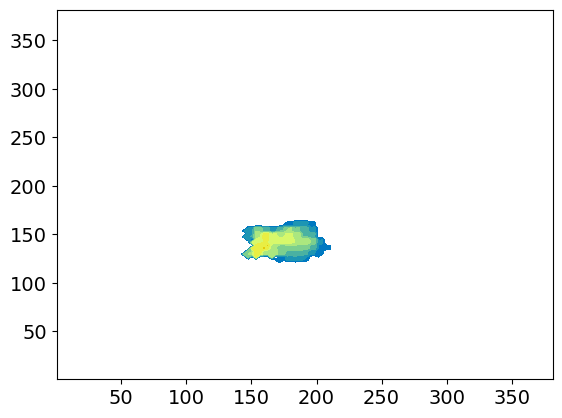

In [181]:
zi = findnearest(zh, 1)

plt.contourf(xh, yh, dbz[zi],  cmap=ctables.REF_default, levels=np.arange(7,80,5))
plt.scatter()

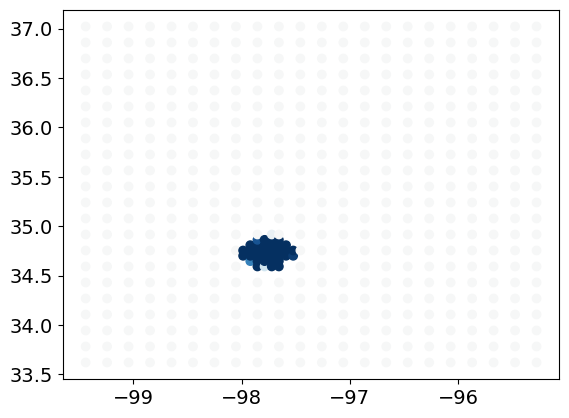

In [93]:
dbz = subdata[subdata.kind==12]

plt.scatter(dbz.lon, dbz.lat, c=dbz.value, cmap='RdBu', norm=plt.Normalize(vmin=-10, vmax=10))

# plt.xlim(0, 384)
# plt.ylim(0,384)

In [126]:
import matplotlib.tri as tri

subdata = pd.read_csv('Obs/8may24_cm1_obs.csv')



In [149]:
temp.value.mean()

np.float64(2.3619529437411715)

In [154]:


triang = tri.Triangulation(temp.y*1000+180, temp.x*1000+180)
interpolator = tri.LinearTriInterpolator(triang, temp.value.values)
zi = interpolator(Xi,Yi)

In [160]:
np.nanmax(zi)

masked

In [151]:
from scipy.interpolate import griddata
zi = griddata((temp.x*1000+180, temp.y*1000+180), temp.value.values, (xi[None, :], yi[:, None]), method='linear')

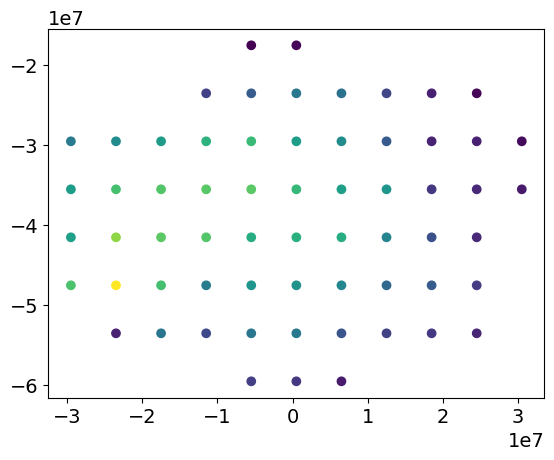

In [152]:
plt.scatter(temp.x*1000+180, temp.y*1000+180, c=temp.value.values)

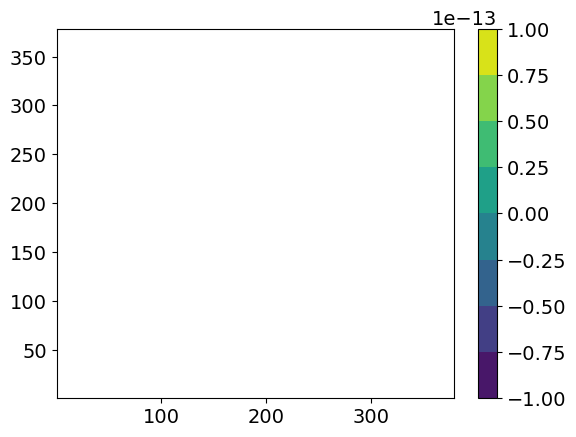

In [155]:
plt.contourf(Xi, Yi, zi)
plt.colorbar()

In [139]:
for i in range(1,21):
    os.system(f'cp DBZ_only/LANDUSE.TBL DBZ_only/member{i:03d}/')

In [11]:
# make fake VR data
# from create_run_letkf for reference lat/lon
radar_lat =  35.23583
radar_lon = -97.46194

total_count = 0
start_time = DT.datetime(2024,5,8,20)

for i,f in enumerate(allfiles[19:20]):
    print(f)

    data_time = start_time + DT.timedelta(minutes=i*5)

    cm1 = xr.open_dataset(f, decode_timedelta=True)

    x,y = cm1.xh.values, cm1.yh.values 
    lev1 = findnearest(cm1.zh.values, 8)
    
    for lev in [0]:
        data = cm1.dbz[0,lev1,:,:].values
        interp = RegularGridInterpolator((y,x), data)
        y6km, x6km = np.meshgrid(cm1.yh[::6], cm1.yh[::6])
        data6km = interp((y6km, x6km)).reshape(np.shape(y6km))
        
        temp = pd.DataFrame(columns=names)
        N_obs = len(x6km.flatten())
        temp['x']         = x6km.flatten()*1000
        temp['y']         = y6km.flatten()*1000
        temp['z']         = [lev*1000]*N_obs
        temp['value']     = data6km.flatten()
        temp['kind']      = [12]*N_obs
        temp['error_var'] = [4]*N_obs
        temp['date']      = [data_time]*N_obs
        temp['days']      = int(cftime.date2num(data_time,day_utime))*N_obs
        temp['seconds']   = [data_time.hour*3600 + data_time.minute*60]*N_obs
        temp['utime']     = [cftime.date2num(data_time,sec_utime)]*N_obs
    


/work/jessica.mcdonald/LETKF_Nature_Run/cm1out_000020.nc


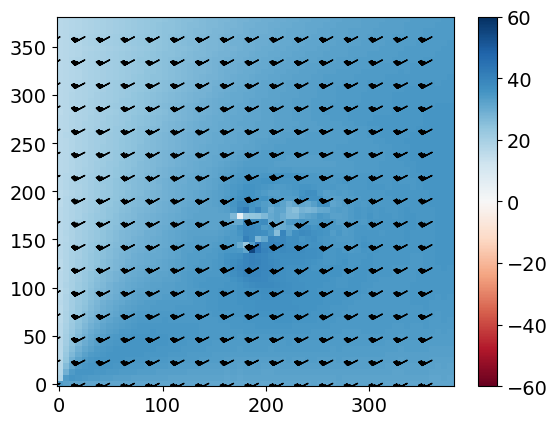

In [22]:
r = np.hypot(y6km, x6km)
vr = (x6km/r)*ui + (y6km/r)*vi
fig, ax = plt.subplots()
pm = ax.pcolormesh(x6km, y6km, vr, vmin=-60, vmax=60, cmap='RdBu')
plt.colorbar(pm)
ax.barbs(x6km[::4,::4], y6km[::4,::4], ui[::4,::4], vi[::4,::4], length=4)

In [13]:
azimuths = np.rad2deg(np.arctan2(x.copy(),y.copy()))
uproj=u*(1.-np.sin(np.deg2rad(azimuths)))
vproj=v*(1.-np.cos(np.deg2rad(azimuths)))


fig, ax = plt.subplots()
pm = ax.pcolormesh(x, y, -1*(uproj+vproj), vmin=-60, vmax=60, cmap='cmo.balance')
plt.colorbar(pm)

array([[31.43271446, 31.43483734, 31.43444443, ..., 31.39610863,
        31.52301407, 31.48962021],
       [31.4347496 , 31.43719482, 31.43702126, ..., 31.42286491,
        31.46860123, 31.50737572],
       [31.43953133, 31.4415226 , 31.44055176, ..., 31.47344589,
        31.41407394, 31.54671669],
       ...,
       [31.50780487, 31.50732231, 31.49713326, ..., 31.50005341,
        31.47526169, 31.48417664],
       [31.42850494, 31.42781448, 31.43678665, ..., 31.46342087,
        31.47148514, 31.40026283],
       [31.65622711, 31.6546669 , 31.64650345, ..., 31.45118523,
        31.41384125, 31.43534088]])

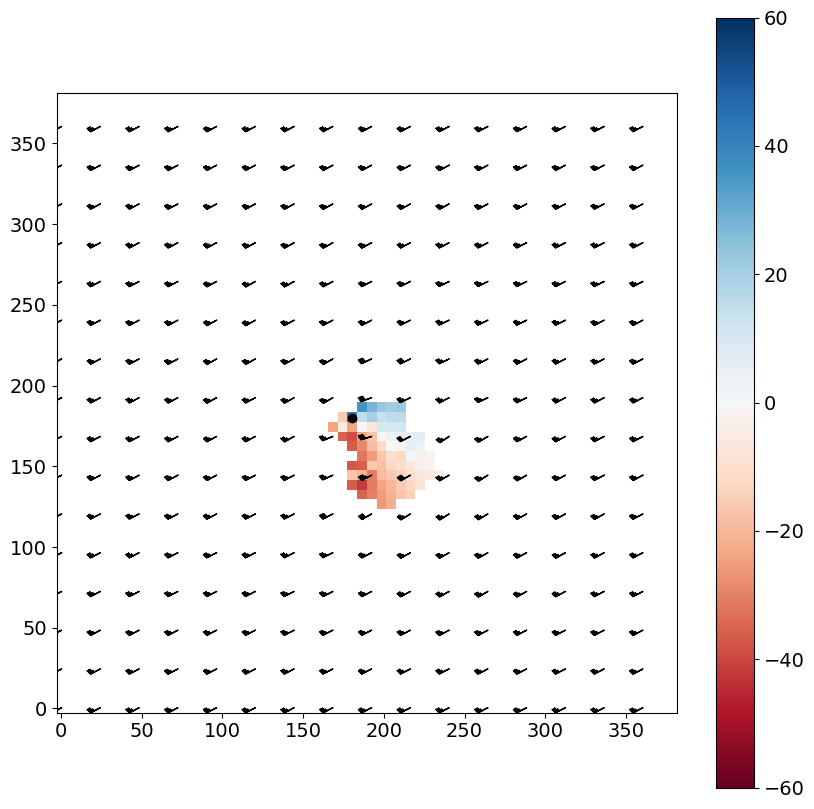

In [19]:
azimuths = np.rad2deg(np.arctan2((x6km.copy()-180)*1000,(y6km.copy()-180)*1000))
# uproj=ui*(1.-np.sin(np.deg2rad(azimuths)))
# vproj=vi*(1.-np.cos(np.deg2rad(azimuths)))

uproj=ui*(np.cos(np.deg2rad(azimuths)))
vproj=vi*(np.sin(np.deg2rad(azimuths)))
Vr = uproj+vproj

fig, ax = plt.subplots(figsize=(10,10))
ax.set_aspect('equal')
mask = (data6km < 10)
Vr[mask] = np.nan
pm = ax.pcolormesh(x6km, y6km, Vr,  vmin=-60, vmax=60, cmap='RdBu')#-1*(uproj+vproj),
plt.colorbar(pm)
plt.scatter(180,180, color='k')

ax.barbs(x6km[::4,::4], y6km[::4,::4], ui[::4,::4], vi[::4,::4], length=4)

In [20]:
subdata = pd.read_csv('Obs/8may24_cm1_radar_obs.csv')

data_time = DT.datetime(2024,5,8,20,55)
dates = cftime.date2num(data_time,sec_utime)
subdata = subdata[(subdata.kind==11)&(subdata.height<1200)&(subdata.height>800)&(subdata.utime==dates)]
#subdata

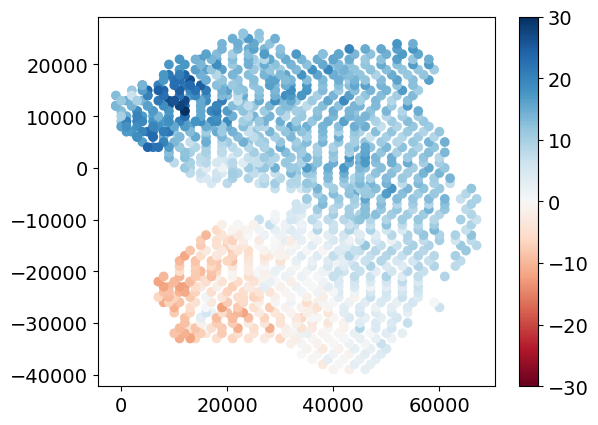

In [21]:
plt.scatter(subdata.x, subdata.y, c=subdata.value, cmap='RdBu', norm=plt.Normalize(vmin=-30, vmax=30))
plt.colorbar()

In [195]:
azimuths = np.rad2deg(np.arctan2((x6km.copy()-180)*1000,(y6km.copy()-180)*1000))


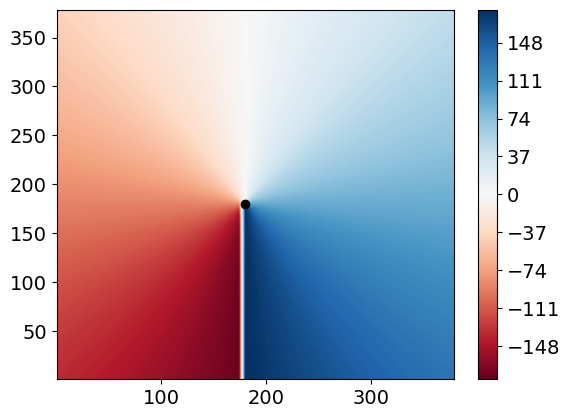

In [196]:
plt.contourf(x6km,y6km,azimuths, cmap='RdBu', levels=np.arange(-180,181,1))
plt.colorbar()
plt.scatter(180,180, color='k')

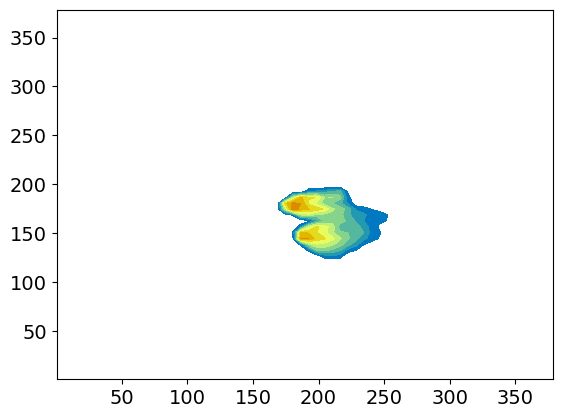

In [68]:
#plt.contourf(cm1.xh, cm1.yh, cm1.dbz[0,lev1], cmap=ctables.REF_default, levels=np.arange(5,75,5))

plt.contourf( x6km, y6km,data6km,levels=np.arange(5,75,5), cmap=ctables.REF_default)#, colors='k', linewidths=0.5)

# making the original obs files from Labriola's PyDART pickle files

In [1]:
import sys
import os
import numpy as N
import math as M
import datetime as DT 
from netCDF4 import *
import pyDart
import ens 
import glob
from optparse import OptionParser
from multiprocessing import Pool
from time import time as timer
from nc_prior_file import *
from assim_util import *
import state_vector as state
import json
import ctables


from pyDart import dxy_2_dll
import pandas as pd
import pickle
import numpy as np
import cftime

import matplotlib.pyplot as plt

import matplotlib as mpl    
plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14) 
plt.rc('axes', labelsize=14, titlesize=18) 
mpl.rcParams.update({"axes.grid" : False, "grid.color": "0.6",  'grid.linestyle':':',
                    'grid.linewidth':1, 'axes.labelweight':'bold', 'legend.framealpha':1.0})




day_utime   = "days since 1601-01-01 00:00:00"#utime("days since 1601-01-01 00:00:00") JEDIT
sec_utime   = "seconds since 1970-01-01 00:00:00"#utime("seconds since 1970-01-01 00:00:00") JEDIT

truelat1, truelat2 = 30.0, 60.0
map_projection='lcc'

In [2]:
#### PROCESSING MY PICKLE FILES FROM LABRIOLAS PYDART ROUTINE

# from create_run_letkf for reference lat/lon
radar_lat =  35.23583
radar_lon = -97.46194

#data_time = DT.datetime(2003, 5, 8,20,00)

day_utime   = "days since 1601-01-01 00:00:00"#utime("days since 1601-01-01 00:00:00") JEDIT
sec_utime   = "seconds since 1970-01-01 00:00:00"#utime("seconds since 1970-01-01 00:00:00") JEDIT

# variables Hxam, Hxbm, Yb_prime which were size (n obs, 30), and satellite (n obs, 3) were all removed for being 2D
names = ['Hxa_bar', 'Hxb_bar','azimuth', 'cov_group', 'd', 'date', 'days', 'dep', 'elevation', 
        'error_var', 'height', 'index', 'kind', 'lat', 'lon', 'next', 'number', 'platform_dir1', 'platform_dir2', 'platform_dir3',
         'platform_height', 'platform_key', 'platform_lon', 'platform_lat', 'platform_nyquist', 'platform_vert_coord','previous',
          'sdHxa','sdHxb','seconds','utime','value','vert_coord', 'x', 'x_m', 'y', 'y_m', 'z']


files = glob.glob('/work/jessica.mcdonald/LETKF_Nature_Run/*.pickle')
files = sorted(files)

loop_count = 0
#time_count = 0
for f in files:
   
    radar = pickle.load(open(f,"rb"))
    data_time = DT.datetime.strptime(f.split('.')[-2][-14:], '%Y%m%d%H%M%S')
    print(data_time)

    var_names = ['DOPPLER_RADIAL_VELOCITY', 'RADAR_REFLECTIVITY']

    for var in var_names:
        print(var)
    
        datadf = radar.obs['radar_001'][var]
        
        temp   = pd.DataFrame(columns=names)
        
        # read in observations and mask out all nans, we don't need those I don't think
        obs   = datadf['obs'].flatten()
        mask  = np.isnan(obs)==False
        N_obs = mask.sum()
        
        temp['value']     = obs[mask]
        if var == 'DOPPLER_RADIAL_VELOCITY':
            temp['kind']      = [11]*N_obs
        elif var == 'RADAR_REFLECTIVITY':
            temp['kind']      = [12]*N_obs
        else:
            print('uknown variable for processing')
            temp['kind']      = -999.+np.zeros_like(ob)
                        
        temp['x']         = datadf['xloc'].flatten()[mask] - 180000 ## these are the "xoffset"...
        temp['y']         = datadf['yloc'].flatten()[mask] - 180000 ## and "yoffset" values put in create_run_letkf.py!
        
        temp['z']         = datadf['zloc'].flatten()[mask]
        
        ob_lats, ob_lons = dxy_2_dll(temp['x'], temp['y'], radar_lat, radar_lon)
        temp['lat']       = ob_lats
        temp['lon']       = ob_lons
        
        temp['height']    = datadf['zloc'].flatten()[mask]
        temp['elevation'] = np.rad2deg(datadf['elevation'].flatten()[mask])
        temp['azimuth']   = np.rad2deg(datadf['azimuth'].flatten()[mask])-180 #hopefully this is right
        
        #### NOTE - the real data had an error_var set to 4. I am replicating this but I NEED to know where this number came from!
        temp['error_var'] = [4]*N_obs
        temp['date']      = [data_time]*N_obs
        temp['days']      = int(cftime.date2num(data_time,day_utime))*N_obs
        temp['seconds']   = [data_time.hour*3600 + data_time.minute*60]*N_obs
        temp['utime']     = [cftime.date2num(data_time,sec_utime)]*N_obs

        if var == 'RADAR_REFLECTIVITY': # drop a lot of the clear air to save time

            # clear out some of the clear air values
            high_dbz = np.where(temp.value >= 4.0)[0]
            clear_air_locs = np.where(temp.value < 4.0)[0][::100] # only keep every 100th value... lol
            keep_arr = np.concat([high_dbz, clear_air_locs])
            temp = temp.iloc[keep_arr]
            
    
        if loop_count ==0:
            subdata = temp.copy()
            del temp
        else:
            subdata = pd.concat([subdata, temp], ignore_index=True)
            del temp

        loop_count+=1

    # del radar
    
# further thin and prep data
subdata.loc[(subdata.value < 6)&(subdata.height > 2000)&(subdata.kind ==12 ), 'value'] = np.nan
subdata = subdata[np.isnan(subdata.value) == False]
subdata = subdata.iloc[::3]
    
subdata.to_csv('Obs/8may24_cm1_radar_obs.csv', index=None)

# ob_f = pd.read_csv('Obs/big_8may24_cm1_radar_obs.csv')

# new = ob_f.iloc[0: len(ob_f): 3]
# new.to_csv('Obs/8may24_cm1_radar_obs.csv', index=None)

2024-05-08 20:00:00
DOPPLER_RADIAL_VELOCITY
RADAR_REFLECTIVITY
2024-05-08 20:05:00
DOPPLER_RADIAL_VELOCITY
RADAR_REFLECTIVITY
2024-05-08 20:10:00
DOPPLER_RADIAL_VELOCITY


KeyboardInterrupt: 

# convert the original obs 

In [16]:
window=300
#obs_file = 'Obs/8may24_cm1_radar_obs.csv'
obs_file = 'Obs/obs_seq_8may03_2km.h5'
init=False

ob_f = pyDart.pyDART()
ob_f.file(obs_file) 

loop_count=0
names = ['Hxa_bar', 'Hxb_bar','azimuth', 'cov_group', 'd', 'date', 'days', 'dep', 'elevation', 
            'error_var', 'height', 'index', 'kind', 'lat', 'lon', 'next', 'number', 'platform_dir1', 'platform_dir2', 'platform_dir3',
             'platform_height', 'platform_key', 'platform_lon', 'platform_lat', 'platform_nyquist', 'platform_vert_coord','previous',
              'sdHxa','sdHxb','seconds','utime','value','vert_coord', 'x', 'x_m', 'y', 'y_m', 'z']

for time_dt in np.arange(65, 90, 5):
    
    # loop over delta times
    analysis_time = DT.datetime(2003,5,8,21,0) + DT.timedelta(minutes=int(time_dt))
    fake_time = DT.datetime(2024,5,8,20,0)+ DT.timedelta(minutes=int(time_dt))
    
    dt     = DT.timedelta(0,int(window/2))
    begin  = analysis_time - dt
    ending = analysis_time + dt
    
    ob_f.search(start=begin.timetuple()[:6], end=ending.timetuple()[:6])
    real = ob_f.get_data()
    

    ddict = {}
    for name in names:
        ddict[name] = real[name]
    df = pd.DataFrame(ddict)
    N_obs = len(df.index)
    # now update utime, date, days, seconds
    df['date']      = [fake_time]*N_obs
    df['days']      = int(cftime.date2num(fake_time,day_utime))*N_obs
    df['seconds']   = [fake_time.hour*3600 + fake_time.minute*60]*N_obs
    df['utime']     = [cftime.date2num(fake_time,sec_utime)]*N_obs
    
    if loop_count ==0:
        subdata = df.copy()
        del df
    else:
        subdata = pd.concat([subdata, df], ignore_index=True)
        del df
    
    loop_count+=1

#subdata.to_csv('Obs/fake_real_radar_obs.csv', index=None)

  pyDART.search:  no variable supplied....all vars dumped
  pyDART.search:  Start datetime:  2003-05-08 22:02:30
  pyDART.search:  End datetime:  2003-05-08 22:02:30

  pyDART file is version:  pyDART_file_version_2.3 
  \/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/

  PyDART SEARCH START TIME  2003-05-08 22:02:30  /  UTIME_START: 1052431350
  PyDART SEARCH END   TIME  2003-05-08 22:07:30  /  UTIME_END:   1052431650
  PyDART converted utimes: 2003-05-08 22:02:30

  PyDART SEARCH CONDITION IS: (1052431350 <= utime) & (utime < 1052431650)

  pyDART file is version:  pyDART_file_version_2.3 
  \/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/

  pyDART.search:  no variable supplied....all vars dumped
  pyDART.search:  Start datetime:  2003-05-08 22:07:30
  pyDART.search:  End datetime:  2003-05-08 22:07:30

  pyDART file is version:  pyDART_file_version_2.3 
  \/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/

  PyDART SEARCH START TIME  2003-05-08 22:07:30 

TypeError: object of type 'NoneType' has no len()

In [66]:
subdata.to_csv('Obs/fake_real_radar_obs.csv', index=None)

# prep observations for DA

In [2]:
import sys
import os
import numpy as N
import math as M
import datetime as DT 
from netCDF4 import *
import pyDart
import ens 
import glob
from optparse import OptionParser
from multiprocessing import Pool
from time import time as timer
from nc_prior_file import *
from assim_util import *
import state_vector as state
import json
import ctables


from pyDart import dxy_2_dll
import pandas as pd
import pickle
import numpy as np
import cftime

import matplotlib.pyplot as plt

import matplotlib as mpl    
plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14) 
plt.rc('axes', labelsize=14, titlesize=18) 
mpl.rcParams.update({"axes.grid" : False, "grid.color": "0.6",  'grid.linestyle':':',
                    'grid.linewidth':1, 'axes.labelweight':'bold', 'legend.framealpha':1.0})




day_utime   = "days since 1601-01-01 00:00:00"#utime("days since 1601-01-01 00:00:00") JEDIT
sec_utime   = "seconds since 1970-01-01 00:00:00"#utime("seconds since 1970-01-01 00:00:00") JEDIT

truelat1, truelat2 = 30.0, 60.0
map_projection='lcc'

In [5]:
myDTstring = '2024,05,08,20,00,00,00'
time = [2024,5,8,20,00,0]
analysis_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))

with open('/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/RUN_LETKF.exp', 'rb') as f:
    exper = json.load(f)
files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False,)

state = ens.read_CM1_ens(files, exper, state_vector=state.Hxf, DateTime=analysis_time)   
ens.ens_CM1_C2A(state)
ens.ens_CM1_coords(state)

obs_file  = 'Obs/8may24_cm1_radar_obs.csv'#exper['radar_obs']
window    = int(exper['DA_PARAMS']['assim_window'])
obs_error = exper['DA_PARAMS']['obs_errors']

ob_f = pd.read_csv(obs_file)

g_lat_max = state.late[:].max()
g_lat_min = state.late[:].min()
g_lon_max = state.lone[:].max()
g_lon_min = state.lone[:].min()
g_alt_max = max(state.zc.data[:]) + state.hgt
g_alt_min = min(state.zc.data[:]) + state.hgt

dt     = DT.timedelta(0,int(window/2))
begin  = cftime.date2num(analysis_time - dt, sec_utime)
ending = cftime.date2num(analysis_time + dt, sec_utime)

data_mask = (ob_f.utime >= begin)   & (ob_f.utime <= ending)  & \
            (ob_f.lat <= g_lat_max) & (ob_f.lat >= g_lat_min) & \
            (ob_f.lon <= g_lon_max) & (ob_f.lon >= g_lon_min)

subdata = ob_f[data_mask]
# thin and prep data
# subdata.loc[(subdata.value < 6)&(subdata.height > 2000)&(subdata.kind ==12 ), 'value'] = np.nan
# subdata = subdata[np.isnan(subdata.value) == False]
# subdata = subdata.iloc[::3]


# len(new_subdata)
nVR = subdata[subdata.kind==11]
nDBZ = subdata[subdata.kind==12]

FileNotFoundError: [Errno 2] No such file or directory: '/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/RUN_LETKF.exp'

In [7]:
ob_f = pd.read_csv(obs_file)

g_lat_max = state.late[:].max()
g_lat_min = state.late[:].min()
g_lon_max = state.lone[:].max()
g_lon_min = state.lone[:].min()
g_alt_max = max(state.zc.data[:]) + state.hgt
g_alt_min = min(state.zc.data[:]) + state.hgt

for time_dt in np.arange(0, 90, 5):
    
    # loop over delta times
    analysis_time = DT.datetime(2024,5,8,20,0) + DT.timedelta(minutes=int(time_dt))

    dt     = DT.timedelta(0,int(window/2))
    begin  = cftime.date2num(analysis_time - dt, sec_utime)
    ending = cftime.date2num(analysis_time + dt, sec_utime)

    data_mask = (ob_f.utime >= begin)   & (ob_f.utime <= ending)  & \
            (ob_f.lat <= g_lat_max) & (ob_f.lat >= g_lat_min) & \
            (ob_f.lon <= g_lon_max) & (ob_f.lon >= g_lon_min)

    subdata = ob_f[data_mask]
    keep_loc = np.where((subdata.kind == 11) & (subdata.value > 5))[0][0]
    temp = subdata.iloc[keep_loc]
    print(temp.value, temp.height)

8.181861788888213 5250.359444793314
5.606266872811934 2623.529964618385
7.178387971197223 2748.723710728809
5.132292052389041 491.59085486643016
5.6775010740169005 1238.545015538111
5.132837380907212 483.9384172596037
5.049029892288565 508.9366157464683
5.681164245987488 571.6468220427632
5.400941479925995 545.7175617013127
5.371619793732547 571.6468220427632
6.3881312990301256 682.246475994587
5.8520936220174935 773.432589981705
7.182950630719475 781.4786019846797


IndexError: index 0 is out of bounds for axis 0 with size 0

In [3]:
keep_loc = np.where((subdata.kind == 11) & (subdata.value > 40)& (subdata.height< 2000)& (subdata.height> 1000))[0][0]
subdata = subdata.iloc[keep_loc]

In [4]:
subdata

,Hxa_bar,Hxb_bar,azimuth,cov_group,d,date,days,dep,elevation,error_var,...,sdHxb,seconds,utime,value,vert_coord,x,x_m,y,y_m,z
0,NaN,NaN,11.842064,NaN,NaN,2024-05-08 20:00:00,3938917250,NaN,0.5,4,...,NaN,72000,1715198400,-8.666324,NaN,-12999.984375,NaN,-61999.992188,NaN,787.936570
1,NaN,NaN,9.162334,NaN,NaN,2024-05-08 20:00:00,3938917250,NaN,0.5,4,...,NaN,72000,1715198400,-12.343791,NaN,-9999.984375,NaN,-61999.992188,NaN,779.867049
2,NaN,NaN,6.441587,NaN,NaN,2024-05-08 20:00:00,3938917250,NaN,0.5,4,...,NaN,72000,1715198400,-12.364496,NaN,-6999.984375,NaN,-61999.992188,NaN,771.826914
3,NaN,NaN,12.925987,NaN,NaN,2024-05-08 20:00:00,3938917250,NaN,0.5,4,...,NaN,72000,1715198400,-12.242240,NaN,-13999.984375,NaN,-60999.992188,NaN,775.039441
4,NaN,NaN,10.222156,NaN,NaN,2024-05-08 20:00:00,3938917250,NaN,0.5,4,...,NaN,72000,1715198400,-15.147571,NaN,-10999.984375,NaN,-60999.992188,NaN,765.415965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21159,NaN,NaN,-70.016991,NaN,NaN,2024-05-08 20:00:00,104253123000,NaN,8.0,4,...,NaN,72000,1715198400,0.000000,NaN,11000.015625,NaN,-3999.984375,NaN,1650.269027
21160,NaN,NaN,-149.036217,NaN,NaN,2024-05-08 20:00:00,104253123000,NaN,8.0,4,...,NaN,72000,1715198400,1.083151,NaN,6000.015625,NaN,10000.015625,NaN,1636.216265
21161,NaN,NaN,-105.945480,NaN,NaN,2024-05-08 20:00:00,104253123000,NaN,10.0,4,...,NaN,72000,1715198400,0.000000,NaN,7000.015625,NaN,2000.015625,NaN,1270.669930
21162,NaN,NaN,-165.963599,NaN,NaN,2024-05-08 20:00:00,104253123000,NaN,12.5,4,...,NaN,72000,1715198400,0.000000,NaN,1000.015625,NaN,4000.015625,NaN,910.034823


In [16]:
import ens

In [17]:
x = np.array([10])
x.max()

idx, Hxf, kind, lat, lon, height, elev, azimuth = ens.calcHx(state, 
                                                               np.array([subdata['kind']]), 
                                                               np.array([subdata['lat']]),                                         
                                                               np.array([subdata['lon']]),
                                                               np.array([subdata['height']]),
                                                               np.array([subdata['elevation']]), 
                                                               np.array([subdata['azimuth']]))

 calcHx:  OBS   LAT MIN/MAX:   34.77688783647445 34.77688783647445
 calcHx:  MODEL LAT MIN/MAX:   33.62953247125773 37.058100351453895
 calcHx:  OBS   LON MIN/MAX:   -97.82551529012142 -97.82551529012142
 calcHx:  MODEL LON MIN/MAX:   -99.42855179656584 -95.2309098106186
 calcHx:  OBS   HGT MIN/MAX:   746.295964634046 746.295964634046
 calcHx:  MODEL HGT MIN/MAX:   75.0 19700.0


In [20]:
import numpy as N

lat     = N.empty((0))
lon     = N.empty((0))
dates   = N.empty((0))
value   = N.empty((0))
kind    = N.empty((0))
height  = N.empty((0))
elev    = N.empty((0))
az      = N.empty((0))
err_var = N.empty((0))
idx     = N.empty((0))

In [22]:
err_var = N.append(err_var, subdata['error_var'])   
value   = N.append(value,   subdata['value'])
dates   = N.append(dates,   subdata['date'])

In [19]:
## note - you can't use time index for state AND for the PAR dataset so you'll need to fake it

window=300
#obs_file = 'Obs/8may24_cm1_radar_obs.csv'
obs_file = 'Obs/obs_seq_8may03_2km.h5'
init=False

ob_f = pyDart.pyDART()
ob_f.file(obs_file) 

analysis_time = DT.datetime(2003,5,8,21,50)

dt     = DT.timedelta(0,int(300/2))#DT.timedelta(0,int(18000/2))
#dt     = DT.timedelta(0,int(18000/2))
begin  = analysis_time - dt
ending = analysis_time + dt

ob_f.search(start=begin.timetuple()[:6], end=ending.timetuple()[:6])
subdata = ob_f.get_data()

# convert to a pandas dataframe for easier comparison 
ddict = {'kind':subdata['kind'], 'lat':subdata['lat'],'lon':subdata['lon'],'height':subdata['height'],
        'elevation':subdata['elevation'],'azimuth':subdata['azimuth'],'value':subdata['value'],'utime':subdata['value']}

df = pd.DataFrame(ddict)
VR = df[df.kind==11]
DBZ = df[df.kind==12]

  pyDART.search:  no variable supplied....all vars dumped
  pyDART.search:  Start datetime:  2003-05-08 21:47:30
  pyDART.search:  End datetime:  2003-05-08 21:47:30

  pyDART file is version:  pyDART_file_version_2.3 
  \/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/

  PyDART SEARCH START TIME  2003-05-08 21:47:30  /  UTIME_START: 1052430450
  PyDART SEARCH END   TIME  2003-05-08 21:52:30  /  UTIME_END:   1052430750
  PyDART converted utimes: 2003-05-08 21:47:30

  PyDART SEARCH CONDITION IS: (1052430450 <= utime) & (utime < 1052430750)

  pyDART file is version:  pyDART_file_version_2.3 
  \/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/



169867
141491
165986
192348


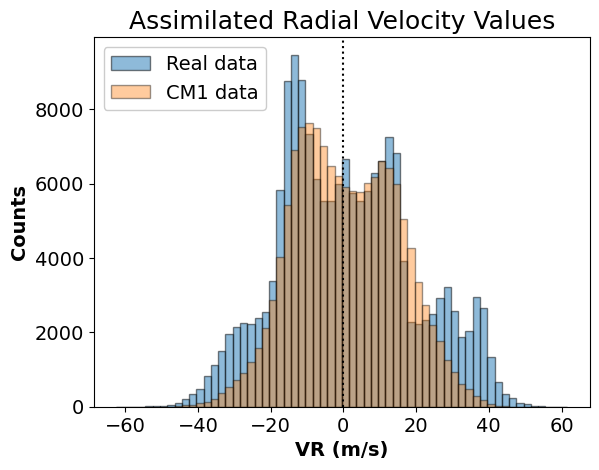

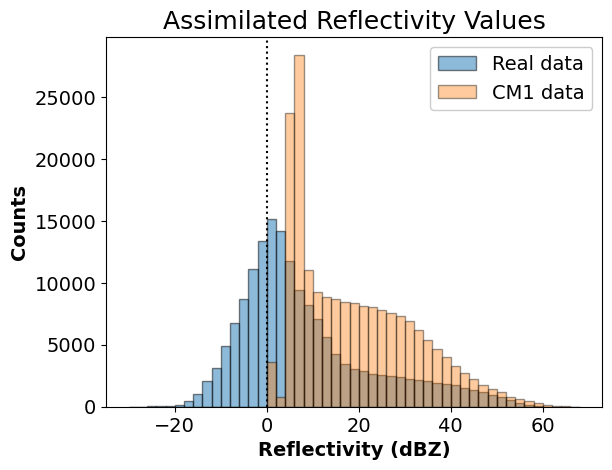

In [9]:
############## VELOCITY

maxVR = (np.max([VR.value.max(), -1*VR.value.min(),-1*VR.value.min(), nVR.value.max()]))
bins = np.arange(-1*maxVR, maxVR, 2)
counts, bin_edges  = np.histogram(VR.value, bins=bins)
ncounts, nbin_edges  = np.histogram(nVR.value, bins=bins)

print(sum(counts))
print(sum(ncounts))

bin_c= (bin_edges[:-1] + bin_edges[1:]) / 2
nbin_c = (nbin_edges[:-1] + nbin_edges[1:]) / 2

fig=plt.figure()
plt.title('Assimilated Radial Velocity Values')
plt.bar(bin_c, counts, width=2, edgecolor='k', alpha=0.5, label='Real data')
plt.bar(nbin_c, ncounts, width=2, edgecolor='k', alpha=0.4, label='CM1 data')
plt.legend(fontsize=14, loc=2)
plt.xlabel('VR (m/s)')
plt.ylabel('Counts')
plt.axvline(0, color='k', ls=':')

############## REFLECTIVITY

maxdbz = (np.max([DBZ.value.max(), nDBZ.value.max()]))
bins = np.arange(-30, maxdbz, 2)
counts, bin_edges  = np.histogram(DBZ.value, bins=bins)
ncounts, nbin_edges  = np.histogram(nDBZ.value, bins=bins)

print(sum(counts))
print(sum(ncounts))

bin_c= (bin_edges[:-1] + bin_edges[1:]) / 2
nbin_c = (nbin_edges[:-1] + nbin_edges[1:]) / 2

fig=plt.figure()
plt.title('Assimilated Reflectivity Values')
plt.bar(bin_c, counts, width=2, edgecolor='k', alpha=0.5, label='Real data')
plt.bar(nbin_c, ncounts, width=2, edgecolor='k', alpha=0.4, label='CM1 data')
plt.legend(fontsize=14)
plt.xlabel('Reflectivity (dBZ)')
plt.ylabel('Counts')
plt.axvline(0, color='k', ls=':')

(33.61603409646708, 37.071598726244545)

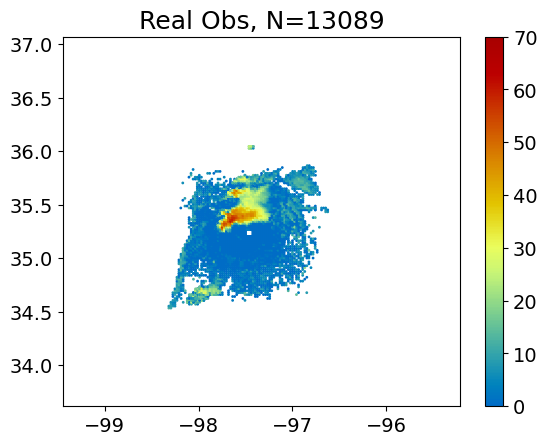

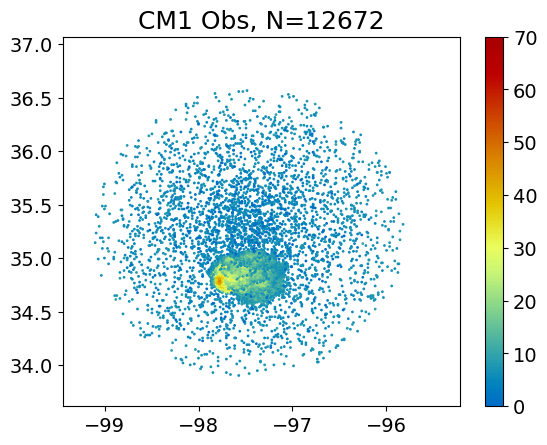

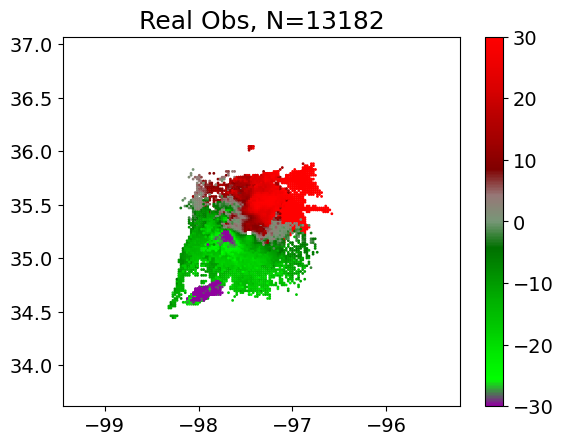

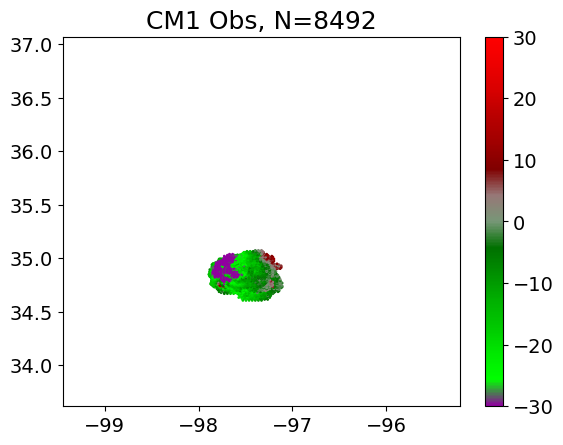

In [20]:

fig = plt.figure()
plt.title(f'Real Obs, N={len(DBZ)}')
plt.scatter(DBZ.lon, DBZ.lat, c=DBZ.value, cmap=ctables.REF_default, norm=P.Normalize(vmin=0, vmax=70),s=1)
plt.colorbar()
plt.xlim(g_lon_min, g_lon_max)
plt.ylim(g_lat_min, g_lat_max)


fig = plt.figure()
plt.title(f'CM1 Obs, N={len(nDBZ)}')
plt.scatter(nDBZ.lon, nDBZ.lat, c=nDBZ.value, cmap=ctables.REF_default, norm=P.Normalize(vmin=0, vmax=70),s=1)
plt.colorbar()
plt.xlim(g_lon_min, g_lon_max)
plt.ylim(g_lat_min, g_lat_max)

fig = plt.figure()
plt.title(f'Real Obs, N={len(VR)}')
plt.scatter(VR.lon, VR.lat, c=VR.value, cmap=ctables.NWSVel, norm=P.Normalize(vmin=-30, vmax=30),s=1)
plt.colorbar()
plt.xlim(g_lon_min, g_lon_max)
plt.ylim(g_lat_min, g_lat_max)


fig = plt.figure()
plt.title(f'CM1 Obs, N={len(nVR)}')
plt.scatter(nVR.lon, nVR.lat, c=nVR.value, cmap=ctables.NWSVel, norm=P.Normalize(vmin=-30, vmax=30),s=1)
plt.colorbar()
plt.xlim(g_lon_min, g_lon_max)
plt.ylim(g_lat_min, g_lat_max)

# prep obs for plotting

In [67]:
ctables.

<module 'ctables' from '/work/jessica.mcdonald/CM1_LETKF_2025/ctables.py'>